In [ ]:
import os
import shutil

base_path = "/content/drive/MyDrive/UASpeech database/audio/words"
target_path = "/content/drive/MyDrive/vlow_filtered_digits"

speakers = ["M01", "M04","M12","F03"]
digits = [f"D{i}" for i in range(10)]

os.makedirs(target_path, exist_ok=True)

for speaker in speakers:
    for digit in digits:
        digit_path = os.path.join(base_path, speaker, digit)

        if not os.path.exists(digit_path):
            continue

        for file in os.listdir(digit_path):
            if file.endswith(".wav"):

                # OPTIONAL: only use mic M3
                # if "_M3.wav" not in file:
                #     continue

                shutil.copy(
                    os.path.join(digit_path, file),
                    os.path.join(target_path, file)
                )

print("Done: Extracted D0–D9 for selected speakers")

Done: Extracted D0–D9 for selected speakers


In [ ]:
import os
import torch
import librosa
import numpy as np
from torch.utils.data import Dataset

class SpeechDataset(Dataset):
    def __init__(self, folder):
        self.files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".wav")]

    def __len__(self):
        return len(self.files)

    def extract_features(self, file):
        y, sr = librosa.load(file, sr=None)

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

        # FIXED SIZE (important!)
        if mfcc.shape[1] < 100:
            pad_width = 100 - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :100]

        return mfcc

    def __getitem__(self, idx):
        file = self.files[idx]

        mfcc = self.extract_features(file)
        mfcc = torch.tensor(mfcc).unsqueeze(0).float()  # (1, 40, 100)

        label = int(file.split("_")[2][1])  # D0 → 0

        return mfcc, label

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(32 * 10 * 25, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # (16,20,50)
        x = self.pool(F.relu(self.conv2(x)))   # (32,10,25)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
from torch.utils.data import DataLoader
import torch.optim as optim

dataset = SpeechDataset(target_path)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    total_loss = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 101.6005
Epoch 2, Loss: 25.8177
Epoch 3, Loss: 8.2693
Epoch 4, Loss: 2.2177
Epoch 5, Loss: 0.4957
Epoch 6, Loss: 0.1488
Epoch 7, Loss: 0.0947
Epoch 8, Loss: 0.0595
Epoch 9, Loss: 0.0459
Epoch 10, Loss: 0.0372


In [ ]:
def predict(file, model):
    model.eval()

    y, sr = librosa.load(file, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

    if mfcc.shape[1] < 100:
        mfcc = np.pad(mfcc, ((0,0),(0,100-mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :100]

    mfcc = torch.tensor(mfcc).unsqueeze(0).unsqueeze(0).float()

    with torch.no_grad():
        output = model(mfcc)
        pred = torch.argmax(output, dim=1).item()

    return pred

In [ ]:
print(predict("/content/drive/MyDrive/filtered_digits/M08_B1_D3_M5.wav", model))

1


In [ ]:
from collections import Counter

labels = []

for file in os.listdir("filtered_digits"):
    label = int(file.split("_")[2][1])
    labels.append(label)

print(Counter(labels))

Counter({1: 21, 3: 21, 4: 21, 2: 21, 0: 21, 5: 13})


In [ ]:
import os

files = os.listdir("filtered_digits")

for f in files[:20]:
    print(f)

M08_B2_D1_M7.wav
M08_B2_D1_M6.wav
M08_B2_D3_M6.wav
M08_B1_D1_M4.wav
M08_B3_D1_M7.wav
M08_B2_D4_M6.wav
M08_B1_D2_M7.wav
M08_B1_D5_M2.wav
M08_B2_D3_M8.wav
M08_B1_D3_M6.wav
M08_B2_D4_M7.wav
M08_B3_D5_M4.wav
M08_B1_D1_M8.wav
M08_B1_D2_M2.wav
M08_B1_D5_M3.wav
M08_B3_D0_M3.wav
M08_B3_D3_M4.wav
M08_B2_D0_M2.wav
M08_B2_D0_M8.wav
M08_B3_D2_M2.wav


In [ ]:
for speaker in speakers:
    for digit in digits:
        path = os.path.join(base_path, speaker, digit)

        if not os.path.exists(path):
            print("Missing:", path)

wav2vec

In [ ]:
import os
import shutil

source = "/content/drive/MyDrive/vlow_filtered_digits"

train_dir = "data/train"
test_dir = "data/test"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

for file in os.listdir(source):
    if not file.endswith(".wav"):
        continue

    if "_B2_" in file:
        shutil.copy(os.path.join(source, file), os.path.join(test_dir, file))
    else:
        shutil.copy(os.path.join(source, file), os.path.join(train_dir, file))

print("Dataset split complete")

Dataset split complete


In [ ]:
from collections import Counter

def count_labels(folder):
    labels = []
    for f in os.listdir(folder):
        labels.append(int(f.split("_")[2][1]))
    return Counter(labels)

print("Train labels:", count_labels("data/train"))
print("Test labels:", count_labels("data/test"))

Train labels: Counter({3: 71, 0: 71, 2: 71, 4: 71, 6: 71, 8: 71, 7: 71, 9: 71, 5: 71, 1: 71})
Test labels: Counter({8: 36, 1: 36, 0: 36, 9: 36, 2: 36, 4: 36, 3: 36, 6: 36, 7: 36, 5: 36})


In [ ]:
import os
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Processor, Wav2Vec2Model

In [ ]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    inputs = [item[0] for item in batch]
    labels = torch.tensor([item[1] for item in batch])

    # pad all sequences to same length
    inputs_padded = pad_sequence(inputs, batch_first=True)

    return inputs_padded, labels

In [ ]:
class WavDataset(Dataset):
    def __init__(self, folder, processor):
        self.files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".wav")]
        self.processor = processor

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file = self.files[idx]

        waveform, sr = torchaudio.load(file)

        # Resample to 16kHz
        if sr != 16000:
            resampler = torchaudio.transforms.Resample(sr, 16000)
            waveform = resampler(waveform)

        waveform = waveform.squeeze()

        inputs = self.processor(
            waveform,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        label = int(file.split("_")[2][1])

        return inputs.input_values.squeeze(0), label

In [ ]:
class Wav2VecClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.wav2vec = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
        self.classifier = nn.Linear(768, 10)

    def forward(self, x):
        outputs = self.wav2vec(x)
        x = outputs.last_hidden_state.mean(dim=1)
        x = self.classifier(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")

train_dataset = WavDataset("data/train", processor)
test_dataset = WavDataset("data/test", processor)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, collate_fn=collate_fn)

model = Wav2VecClassifier().to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
for param in model.wav2vec.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

In [ ]:
epochs = 7

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 2.3155
Epoch 2, Loss: 2.3146
Epoch 3, Loss: 2.3128
Epoch 4, Loss: 2.3122
Epoch 5, Loss: 2.3145
Epoch 6, Loss: 2.3121
Epoch 7, Loss: 2.3118


In [ ]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    return accuracy, all_preds, all_labels

In [ ]:
acc, preds, labels = evaluate(model, test_loader)
print("Test Accuracy:", acc)

Test Accuracy: 0.8642857142857143


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(labels, preds)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[14  0  0  0  0  0  0  0  0  0]
 [ 0 13  0  0  0  1  0  0  0  0]
 [ 0  0  7  0  0  0  7  0  0  0]
 [ 0  0  0 13  0  0  0  1  0  0]
 [ 0  0  0  0 14  0  0  0  0  0]
 [ 0  0  0  0  0 14  0  0  0  0]
 [ 0  0  0  0  0  0 14  0  0  0]
 [ 0  0  0  0  0  0  0  7  0  7]
 [ 0  0  0  3  0  0  0  0 11  0]
 [ 0  0  0  0  0  0  0  0  0 14]]


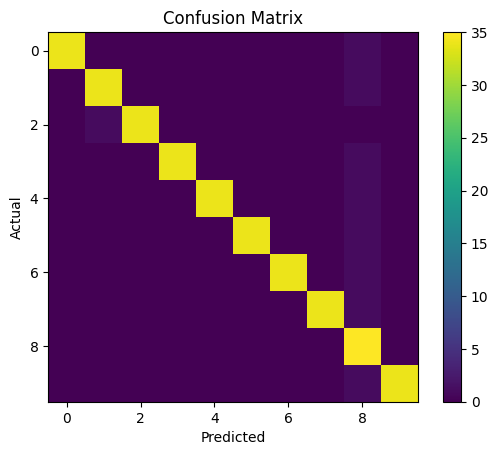

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        35
           1       0.97      0.97      0.97        35
           2       1.00      0.97      0.99        35
           3       1.00      0.97      0.99        35
           4       1.00      0.97      0.99        35
           5       1.00      0.97      0.99        35
           6       1.00      0.97      0.99        35
           7       1.00      0.97      0.99        35
           8       0.81      1.00      0.90        35
           9       1.00      0.97      0.99        35

    accuracy                           0.97       350
   macro avg       0.98      0.97      0.98       350
weighted avg       0.98      0.97      0.98       350



In [ ]:
def predict(file, model, processor):
    model.eval()

    waveform, sr = torchaudio.load(file)

    if sr != 16000:
        resampler = torchaudio.transforms.Resample(sr, 16000)
        waveform = resampler(waveform)

    waveform = waveform.squeeze()

    inputs = processor(
        waveform,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        output = model(inputs.input_values.to(device))
        pred = torch.argmax(output, dim=1).item()

    return pred

In [ ]:
print(predict("data/test/M08_B2_D1_M3.wav", model, processor))

1


In [ ]:
torch.save(model.state_dict(), "wav2vec_digit_model.pth")

In [ ]:
from google.colab import files
files.download("wav2vec_digit_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>